# 07 — LGBM Walk-Forward Optimization (vtrain5)

## What changed vs vtrain4

vtrain4 confirmed that 0.1% taker fees destroy the edge entirely (Sharpe −0.67, return −18%). The root
cause: 897 directional market orders per year × 0.2% round-trip = ~180 pp of gross drag.

vtrain5 switches to a **Passive Market Making** execution model trading Perpetual Futures:

| # | Problem (vtrain4) | Fix applied here |
|---|-------------------|-----------------|
| 1 | Market-order entry → Taker fee every trade | **Pullback limit entry** `Close − entry_atr_mult × ATR` (next-bar fill check) |
| 2 | Limit order assumed filled on any wick touch | **5 bp penetration buffer** — wick must clear `limit_px × (1 ± BUFFER)` to guarantee FIFO queue position |
| 3 | Flat fee structure (0.1% both sides) | **Asymmetric fees**: Maker = 0% (entries, TP exits) / Taker = 0.05% × leverage (SL exits, time exits) |
| 4 | No funding rate | **Funding drag**: 0.00077% per hour × leverage (≈ 0.0062%/8h, MEXC empirical) |
| 5 | No leverage parameter | `LEVERAGE = 1.0` parameter; all fee/funding impacts scaled by leverage |

## Execution state machine

```
FLAT → (signal at T close) → ORDER_PENDING  →  (fill at T+1 if wick clears buffer) → IN_POSITION
                                            ↓  (no fill at T+1) → ORDER_EXPIRES → FLAT
IN_POSITION → SL hit (low/high wick) → exit Taker fee
           → TP hit (opposite wick, buffer penetration required) → exit Maker fee = 0
           → max_hold / conf drop → exit Taker fee
```

Everything else (K=5 purged K-Fold, temporally-matched internal val, expanding-window WFO, same
LightGBM hyperparameters, ATR-relative SL/TP) is unchanged from vtrain4.

In [1]:
SYMBOL   = 'BTCUSDT'
INTERVAL = '1h'
TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

# ── Phase 1: Purged K-Fold ────────────────────────────────────────────────────
K                    = 5
EMBARGO              = 168
KFOLD_INTERNAL_VAL_H = 2500
EARLY_STOPPING_ROUNDS = 50

# ── Phase 2: Walk-Forward Optimization ───────────────────────────────────────
WFO_STEP_H         = 720
WFO_INTERNAL_VAL_H = 2500
WFO_PATIENCE       = 50

# ── Execution model (vtrain6 — same as vtrain5 but with corrected limit_px) ──
MAKER_FEE       = 0.0000   # 0 %  — limit orders (entries, TP exits)
TAKER_FEE       = 0.0005   # 0.05% — market orders (SL exits, time/conf exits)
LEVERAGE        = 1.0      # all fee/funding impacts × leverage
BUFFER          = 0.0005   # 5 bp wick-penetration requirement for limit fill
FUNDING_RATE_H  = 0.0000077  # 0.00077%/h ≈ 0.0062%/8h (MEXC empirical)

# ── Optimisation ─────────────────────────────────────────────────────────────
OPTIMISE_METRIC = 'sharpe'
MIN_TRADES      = 30
TOP_N           = 20

# ── LightGBM hyperparameters (identical to vtrain3/4/5) ──────────────────────
LGB_PARAMS = {
    'objective':         'binary',
    'metric':            'binary_logloss',
    'n_estimators':      1000,
    'learning_rate':     0.02,
    'num_leaves':        31,
    'max_depth':         -1,
    'min_child_samples': 50,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
}

# ── Grid — entry_atr_mult now works correctly (fractional px offset)
# Wider range vs vtrain5 to find the optimal pullback depth after bug fix
GRID = {
    'long_threshold':    [0.54, 0.57, 0.60, 0.63],
    'short_threshold':   [0.37, 0.40, 0.43, 0.46],
    'entry_atr_mult':    [0.3, 0.5, 0.8, 1.2],     # proper pullback: 0.3–1.2 × ATR below close
    'sl_atr_multiplier': [1.5, 2.0, 2.5],
    'tp_atr_multiplier': [1.5, 2.0, 3.0],
    'min_sl':            [0.010, 0.015, 0.020],
    'min_hold':          [4, 8],
    'max_hold':          [24, 48],
    'cooldown':          [2, 3],
}

In [2]:
import itertools
import json
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9,  'ytick.labelsize': 9,
    'legend.fontsize': 9,  'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

REPO_ROOT    = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
RAW_DIR      = REPO_ROOT / 'data' / 'raw'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists(): MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR  = REPO_ROOT / 'figures' / 'grid_lgbm'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT  : {REPO_ROOT}')
print(f'MODELS_DIR : {MODELS_DIR}')
print(f'vtrain6 — Maker={MAKER_FEE*100:.2f}%  Taker={TAKER_FEE*100:.3f}%  '
      f'Leverage={LEVERAGE}  Buffer={BUFFER*1e4:.0f}bp  '
      f'Funding={FUNDING_RATE_H*100:.5f}%/h  '
      f'[BUG FIX: limit_px = px*(1±ent_atr*atr_pct)]')

REPO_ROOT  : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
MODELS_DIR : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models
vtrain6 — Maker=0.00%  Taker=0.050%  Leverage=1.0  Buffer=5bp  Funding=0.00077%/h  [BUG FIX: limit_px = px*(1±ent_atr*atr_pct)]


In [3]:
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

raw_df = pd.read_parquet(RAW_DIR / f'{SYMBOL}_{INTERVAL}.parquet')
raw_df.index = raw_df.index.tz_localize(None) if raw_df.index.tz else raw_df.index
feat_df = feat_df.join(raw_df[['high', 'low']], how='left')
feat_df = feat_df.dropna(subset=['high', 'low'])

train_df, val_df, test_df = calendar_split(feat_df, train_end=TRAIN_END, val_end=VAL_END)
trainval_df = pd.concat([train_df, val_df]).sort_index()

selected_features = pd.read_csv(
    MODELS_DIR / 'lgbm_features.csv', header=None
)[0].tolist()

X_tv   = trainval_df[selected_features].values
y_tv   = trainval_df['label'].values
X_test = test_df[selected_features].values
y_test = test_df['label'].values

def _arr(df, col): return df[col].values.astype(np.float64)

tv_close = _arr(trainval_df, 'close')
tv_high  = _arr(trainval_df, 'high')
tv_low   = _arr(trainval_df, 'low')
tv_atr   = _arr(trainval_df, 'atr_14_pct')
tv_index = trainval_df.index

test_close = _arr(test_df, 'close')
test_high  = _arr(test_df, 'high')
test_low   = _arr(test_df, 'low')
test_atr   = _arr(test_df, 'atr_14_pct')
test_index = test_df.index

print(f'TrainVal : {len(trainval_df):>7,}  {trainval_df.index[0].date()} → {trainval_df.index[-1].date()}')
print(f'Test     : {len(test_df):>7,}  {test_df.index[0].date()} → {test_df.index[-1].date()}')
print(f'Features : {len(selected_features)}')

TrainVal :  61,118  2017-11-15 → 2024-11-10
Test     :  13,248  2024-11-10 → 2026-05-16
Features : 50


## Phase 1 — Purged K-Fold OOS Probabilities

Identical to vtrain4: K=5, embargo=168, internal val from `KFOLD_INTERNAL_VAL_H` bars immediately
before the embargo zone of each fold (edge case fold 1: post-embargo).

In [4]:
n_tv      = len(trainval_df)
fold_size = n_tv // K
oos_probs_tv = np.full(n_tv, np.nan)

t0 = time.perf_counter()
for k in range(K):
    fold_start = k * fold_size
    fold_end   = (k + 1) * fold_size if k < K - 1 else n_tv
    emb_start  = max(0, fold_start - EMBARGO)
    emb_end    = min(n_tv, fold_end + EMBARGO)

    if emb_start >= 200:
        n_int     = min(KFOLD_INTERNAL_VAL_H, emb_start)
        int_end   = emb_start
        int_start = emb_start - n_int
        source    = f'pre-fold [{int_start},{int_end})'
    else:
        n_int     = min(KFOLD_INTERNAL_VAL_H, 1000)
        int_start = emb_end
        int_end   = min(n_tv, emb_end + n_int)
        n_int     = int_end - int_start
        source    = f'post-emb [{int_start},{int_end})'

    mask = np.ones(n_tv, dtype=bool)
    mask[emb_start:emb_end] = False
    mask[int_start:int_end] = False

    ds_tr = lgb.Dataset(X_tv[mask],             label=y_tv[mask],             feature_name=selected_features)
    ds_vl = lgb.Dataset(X_tv[int_start:int_end], label=y_tv[int_start:int_end], feature_name=selected_features, reference=ds_tr)

    fold_model = lgb.train(
        LGB_PARAMS, ds_tr,
        valid_sets=[ds_tr, ds_vl], valid_names=['train', 'val'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    fold_pred = fold_model.predict(X_tv[fold_start:fold_end])
    oos_probs_tv[fold_start:fold_end] = fold_pred
    print(f'Fold {k+1}/{K}  int_val={n_int} ({source})  best_iter={fold_model.best_iteration}  '
          f'prob=[{fold_pred.min():.3f},{fold_pred.max():.3f}]')
    del fold_model

print(f'K-Fold done {time.perf_counter()-t0:.1f}s  coverage={np.isfinite(oos_probs_tv).sum():,}/{n_tv:,}')

Fold 1/5  int_val=1000 (post-emb [12391,13391))  best_iter=98  prob=[0.355,0.679]
Fold 2/5  int_val=2500 (pre-fold [9555,12055))  best_iter=386  prob=[0.252,0.809]
Fold 3/5  int_val=2500 (pre-fold [21778,24278))  best_iter=188  prob=[0.286,0.723]
Fold 4/5  int_val=2500 (pre-fold [34001,36501))  best_iter=100  prob=[0.352,0.693]
Fold 5/5  int_val=2500 (pre-fold [46224,48724))  best_iter=372  prob=[0.264,0.746]
K-Fold done 10.0s  coverage=61,118/61,118


OOS AUC: 0.5766  mean=0.5141  std=0.0668


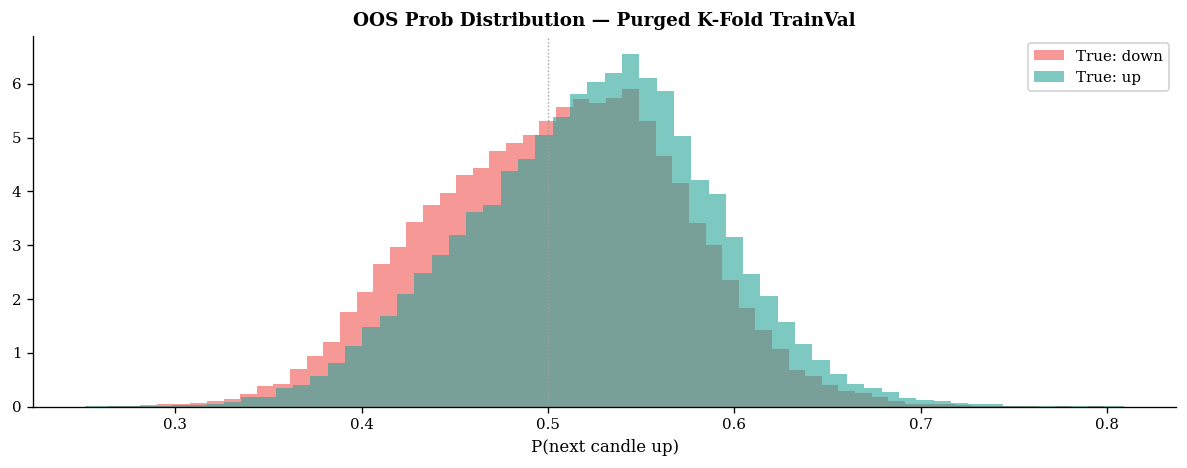

In [5]:
valid_mask = np.isfinite(oos_probs_tv)
oos_index  = trainval_df.index[valid_mask]
oos_probs  = oos_probs_tv[valid_mask]
oos_close  = tv_close[valid_mask]
oos_high   = tv_high[valid_mask]
oos_low    = tv_low[valid_mask]
oos_atr    = tv_atr[valid_mask]
oos_labels = trainval_df['label'].values[valid_mask]

print(f'OOS AUC: {roc_auc_score(oos_labels, oos_probs):.4f}  '
      f'mean={oos_probs.mean():.4f}  std={oos_probs.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(oos_probs[oos_labels == 0], bins=60, alpha=0.6, color=RED,  label='True: down', density=True)
ax.hist(oos_probs[oos_labels == 1], bins=60, alpha=0.6, color=GREEN, label='True: up',  density=True)
ax.axvline(0.5, color=GREY, ls=':', lw=0.8)
ax.set_xlabel('P(next candle up)')
ax.set_title('OOS Prob Distribution — Purged K-Fold TrainVal', fontweight='bold')
ax.legend(); fig.tight_layout()
fig.savefig(FIGURES_DIR / 'oos_prob_distribution_vtrain6.png'); plt.show()

## Phase 1 — Grid Search: Maker-Only Execution

### State machine

**Flat** (no position, no pending order, cooldown=0):
- `P(up) ≥ long_threshold` → place **limit buy** at `Close[T] − entry_atr_mult × ATR[T]`
- `P(up) ≤ short_threshold` → place **limit sell** at `Close[T] + entry_atr_mult × ATR[T]`

**Order pending** (checked on next candle only — Time-In-Force = 1 bar):
- Long fill: `Low[T+1] < limit_px × (1 − BUFFER)` → entry at `limit_px`, **0% Maker fee**
- Short fill: `High[T+1] > limit_px × (1 + BUFFER)` → entry at `limit_px`, **0% Maker fee**
- No fill: order expires, back to Flat (can signal again same bar)

**In position** (from bar `entry_bar+1`):
- **Funding drag** applied every bar: `units × (1 − FUNDING_RATE_H × LEVERAGE)` (long) / same for `entry_cash` (short)
- **SL** (Taker): `Low ≤ sl_price` (long) / `High ≥ sl_price` (short) → exit at SL price, Taker fee × leverage
- **TP** (Maker): `High > tp_price × (1+BUFFER)` (long) / `Low < tp_price × (1−BUFFER)` (short) → exit at TP price, **0% fee**
- **Both hit same candle**: SL wins (pessimistic)
- **Max hold / conf drop** (Taker): exit at close, Taker fee × leverage

### Fee comparison

| Scenario | vtrain4 | vtrain5 |
|----------|---------|---------|
| Entry | 0.1% taker | 0% maker (if filled) |
| TP exit | 0.1% taker | 0% maker |
| SL exit | 0.1% taker | 0.05% taker |
| Time/conf exit | 0.1% taker | 0.05% taker |
| Best-case round-trip | 0.2% | **0%** |
| Worst-case round-trip | 0.2% | **0.1%** |

In [6]:
def run_backtest(probs, close_arr, high_arr, low_arr, atr_arr, sig_index, params,
                 maker_fee=MAKER_FEE, taker_fee=TAKER_FEE, leverage=LEVERAGE,
                 buf=BUFFER, fund_h=FUNDING_RATE_H):
    """Maker-only entry with penetration buffer, asymmetric fees, and funding rate drag."""
    lt         = params['long_threshold']
    st         = params['short_threshold']
    exit_long  = 1.0 - lt
    exit_short = 1.0 - st
    ent_atr    = params['entry_atr_mult']
    sl_m       = params['sl_atr_multiplier']
    tp_m       = params['tp_atr_multiplier']
    min_sl     = params['min_sl']
    min_hold   = int(params['min_hold'])
    max_hold   = int(params['max_hold'])
    cd_n       = int(params['cooldown'])

    taker_eff  = taker_fee * leverage   # effective taker drag per side
    maker_eff  = maker_fee * leverage   # 0.0 — kept explicit for clarity
    fund_eff   = fund_h   * leverage    # funding drag per bar

    cash       = 1.0;  units = 0.0;  entry_cash = 0.0
    in_pos     = False; direction = None
    entry_px   = 0.0;  dynamic_sl = 0.0;  dynamic_tp = 0.0
    hold_count = 0;    cooldown   = 0;    entry_bar  = -1
    pending    = None   # {'direction', 'limit_px', 'sl', 'tp'}

    equity_curve = [1.0]
    trade_log    = []
    # counters for diagnostics
    n_signals = 0; n_fills = 0; n_expires = 0

    N = len(close_arr)
    for i in range(N):
        px   = close_arr[i]
        hi   = high_arr[i]
        lo   = low_arr[i]
        conf = probs[i]
        atr  = atr_arr[i]

        if cooldown > 0:
            cooldown -= 1

        # ── 1. Check pending order fill (Time-In-Force = 1 bar) ──────────────
        if pending is not None:
            lp = pending['limit_px']
            filled = False

            if pending['direction'] == 'long':
                if lo < lp * (1.0 - buf):        # wick penetrates buffer
                    units      = cash * (1.0 - maker_eff) / lp
                    cash       = 0.0
                    in_pos     = True; direction = 'long'
                    entry_px   = lp; entry_bar = i; hold_count = 0
                    dynamic_sl = pending['sl']; dynamic_tp = pending['tp']
                    filled = True; n_fills += 1
                else:
                    n_expires += 1
            else:  # short
                if hi > lp * (1.0 + buf):
                    entry_cash = cash * (1.0 - maker_eff)
                    cash       = 0.0; units = entry_cash / lp
                    in_pos     = True; direction = 'short'
                    entry_px   = lp; entry_bar = i; hold_count = 0
                    dynamic_sl = pending['sl']; dynamic_tp = pending['tp']
                    filled = True; n_fills += 1
                else:
                    n_expires += 1
            pending = None   # order consumed (filled or expired)

        # ── 2. Manage open position (not on entry bar) ────────────────────────
        if in_pos and i > entry_bar:
            hold_count += 1

            # Funding drag (applied to position value each bar)
            if direction == 'long':
                units      *= (1.0 - fund_eff)
            else:
                entry_cash *= (1.0 - fund_eff)

            reason  = None
            exit_px = px
            pnl     = 0.0

            if direction == 'long':
                sl_price  = entry_px * (1.0 - dynamic_sl)
                tp_price  = entry_px * (1.0 + dynamic_tp)
                tp_check  = tp_price * (1.0 + buf)   # wick must clear buffer

                sl_hit = lo <= sl_price
                tp_hit = hi > tp_check

                if sl_hit and tp_hit:          # pessimistic: SL wins
                    reason = 'sl'; exit_px = sl_price
                    pnl  = (exit_px - entry_px) / entry_px
                    cash = units * exit_px * (1.0 - taker_eff); units = 0.0
                elif sl_hit:
                    reason = 'sl'; exit_px = sl_price
                    pnl  = (exit_px - entry_px) / entry_px
                    cash = units * exit_px * (1.0 - taker_eff); units = 0.0
                elif tp_hit:
                    reason = 'tp'; exit_px = tp_price   # fill at exact TP level
                    pnl  = (exit_px - entry_px) / entry_px
                    cash = units * exit_px * (1.0 - maker_eff); units = 0.0
                elif hold_count >= max_hold:
                    reason = 'max_hold'; exit_px = px
                    pnl  = (px - entry_px) / entry_px
                    cash = units * px * (1.0 - taker_eff); units = 0.0
                elif hold_count >= min_hold and conf < exit_long:
                    reason = 'conf'; exit_px = px
                    pnl  = (px - entry_px) / entry_px
                    cash = units * px * (1.0 - taker_eff); units = 0.0

            else:  # short
                sl_price  = entry_px * (1.0 + dynamic_sl)
                tp_price  = entry_px * (1.0 - dynamic_tp)
                tp_check  = tp_price * (1.0 - buf)   # wick must dip below tp*(1-buf)

                sl_hit = hi >= sl_price
                tp_hit = lo < tp_check

                if sl_hit and tp_hit:
                    reason = 'sl'; exit_px = sl_price
                    gross  = (entry_px - exit_px) / entry_px
                    pnl    = gross
                    cash   = entry_cash * (1.0 + gross) * (1.0 - taker_eff)
                elif sl_hit:
                    reason = 'sl'; exit_px = sl_price
                    gross  = (entry_px - exit_px) / entry_px
                    pnl    = gross
                    cash   = entry_cash * (1.0 + gross) * (1.0 - taker_eff)
                elif tp_hit:
                    reason = 'tp'; exit_px = tp_price
                    gross  = (entry_px - exit_px) / entry_px
                    pnl    = gross
                    cash   = entry_cash * (1.0 + gross) * (1.0 - maker_eff)
                elif hold_count >= max_hold:
                    reason = 'max_hold'; exit_px = px
                    gross  = (entry_px - px) / entry_px
                    pnl    = gross
                    cash   = entry_cash * (1.0 + gross) * (1.0 - taker_eff)
                elif hold_count >= min_hold and conf > exit_short:
                    reason = 'conf'; exit_px = px
                    gross  = (entry_px - px) / entry_px
                    pnl    = gross
                    cash   = entry_cash * (1.0 + gross) * (1.0 - taker_eff)

            if reason:
                trade_log.append({'direction': direction, 'pnl_pct': pnl,
                                   'hold_h': hold_count, 'reason': reason})
                in_pos = False; direction = None
                hold_count = 0; cooldown = cd_n

        # ── 3. Place new pending order if flat with no pending ────────────────
        if not in_pos and pending is None and cooldown == 0:
            sl_v = max(sl_m * atr, min_sl)
            tp_v = tp_m * atr
            if conf >= lt:
                # atr_14_pct is a fraction (e.g. 0.005), must multiply by px for dollar offset
                limit_px = px * (1.0 - ent_atr * atr)
                pending  = {'direction': 'long',  'limit_px': limit_px, 'sl': sl_v, 'tp': tp_v}
                n_signals += 1
            elif conf <= st:
                limit_px = px * (1.0 + ent_atr * atr)
                pending  = {'direction': 'short', 'limit_px': limit_px, 'sl': sl_v, 'tp': tp_v}
                n_signals += 1

        # ── Equity valuation ──────────────────────────────────────────────────
        if in_pos and direction == 'long':
            equity_curve.append(units * px)
        elif in_pos and direction == 'short':
            equity_curve.append(entry_cash * (1.0 + (entry_px - px) / entry_px))
        else:
            equity_curve.append(cash)

    # Force-close at end
    if in_pos:
        px = close_arr[-1]
        if direction == 'long':
            gross = (px - entry_px) / entry_px
            cash  = units * px * (1.0 - taker_eff)
        else:
            gross = (entry_px - px) / entry_px
            cash  = entry_cash * (1.0 + gross) * (1.0 - taker_eff)
        trade_log.append({'direction': direction, 'pnl_pct': gross,
                           'hold_h': hold_count, 'reason': 'eod'})
        equity_curve[-1] = cash

    tdf = pd.DataFrame(trade_log)
    # Attach diagnostics as attributes so callers can inspect fill rate
    tdf.attrs['n_signals'] = n_signals
    tdf.attrs['n_fills']   = n_fills
    tdf.attrs['n_expires'] = n_expires
    return np.array(equity_curve[1:]), tdf


def score_equity(equity_arr, trades_df, metric):
    if trades_df.empty: return -np.inf
    eq  = equity_arr
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    ann = 24 * 365
    if metric == 'sharpe':       return float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(ann))
    if metric == 'total_return': return float(eq[-1] - 1)
    if metric == 'calmar':
        ar  = float((eq[-1] ** (ann / len(eq))) - 1)
        pk  = np.maximum.accumulate(eq)
        mdd = float(((eq - pk) / (pk + 1e-12)).min())
        return ar / (abs(mdd) + 1e-6)
    if metric == 'win_rate':     return float((trades_df['pnl_pct'] > 0).mean())
    if metric == 'profit_factor':
        g = trades_df[trades_df['pnl_pct'] > 0]['pnl_pct'].sum()
        l = trades_df[trades_df['pnl_pct'] < 0]['pnl_pct'].abs().sum()
        return float(g / (l + 1e-6))
    return -np.inf


print(f'run_backtest() defined (vtrain6 — limit_px bug fixed) — '
      f'Maker={MAKER_FEE*100:.2f}%  Taker={TAKER_FEE*100:.3f}%  '
      f'Buffer={BUFFER*1e4:.0f}bp  Funding={FUNDING_RATE_H*100:.5f}%/h')

run_backtest() defined (vtrain6 — limit_px bug fixed) — Maker=0.00%  Taker=0.050%  Buffer=5bp  Funding=0.00077%/h


In [7]:
keys   = list(GRID.keys())
combos = list(itertools.product(*[GRID[k] for k in keys]))

# Same directional validity filter as vtrain4
valid_combos = [
    dict(zip(keys, v)) for v in combos
    if v[0] > 0.5
    and v[1] < 0.5
    and v[0] - (1 - v[1]) >= 0.02
]
print(f'Total combos : {len(combos):,}  →  valid: {len(valid_combos):,}')
print(f'Optimising   : {OPTIMISE_METRIC}')

results = []
for params in tqdm(valid_combos, desc='Grid search vtrain6 (OOS maker, fixed limit_px)'):
    eq, tdf = run_backtest(oos_probs, oos_close, oos_high, oos_low, oos_atr, oos_index, params)
    if len(tdf) < MIN_TRADES:
        continue

    s   = score_equity(eq, tdf, OPTIMISE_METRIC)
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    pk  = np.maximum.accumulate(eq)
    fill_rate = tdf.attrs.get('n_fills', 0) / max(tdf.attrs.get('n_signals', 1), 1)

    results.append({
        **params,
        'score':        s,
        'total_return': float(eq[-1] - 1),
        'sharpe':       float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365)),
        'max_dd':       float(((eq - pk) / (pk + 1e-12)).min()),
        'n_trades':     len(tdf),
        'win_rate':     float((tdf['pnl_pct'] > 0).mean()),
        'n_long':       int((tdf['direction'] == 'long').sum()),
        'n_short':      int((tdf['direction'] == 'short').sum()),
        'n_sl':         int((tdf['reason'] == 'sl').sum()),
        'n_tp':         int((tdf['reason'] == 'tp').sum()),
        'n_conf':       int((tdf['reason'] == 'conf').sum()),
        'fill_rate':    fill_rate,
    })

results_df = pd.DataFrame(results).sort_values('score', ascending=False).reset_index(drop=True)
print(f'\nValid results : {len(results_df):,}')
if not results_df.empty:
    print(f'Best {OPTIMISE_METRIC}    : {results_df["score"].iloc[0]:.4f}')
    print(f'Worst {OPTIMISE_METRIC}   : {results_df["score"].iloc[-1]:.4f}')
    print(f'Fill rate     : mean={results_df["fill_rate"].mean():.1%}  '
          f'range=[{results_df["fill_rate"].min():.1%}, {results_df["fill_rate"].max():.1%}]')

Total combos : 13,824  →  valid: 5,184
Optimising   : sharpe


Grid search vtrain6 (OOS maker, fixed limit_px): 100%|██████████| 5184/5184 [02:04<00:00, 41.77it/s]


Valid results : 5,184
Best sharpe    : 1.0120
Worst sharpe   : -1.1412
Fill rate     : mean=25.9%  range=[8.7%, 47.5%]


In [8]:
from IPython.display import display

display_cols = [
    'score', 'total_return', 'sharpe', 'max_dd', 'win_rate', 'fill_rate',
    'n_trades', 'n_long', 'n_short', 'n_sl', 'n_tp',
    'long_threshold', 'short_threshold', 'entry_atr_mult',
    'sl_atr_multiplier', 'tp_atr_multiplier', 'min_sl',
    'min_hold', 'max_hold', 'cooldown',
]
top = results_df[display_cols].head(TOP_N).copy()
for col, fmt in [('total_return','{:+.2%}'), ('max_dd','{:.2%}'), ('win_rate','{:.1%}'),
                 ('fill_rate','{:.1%}'), ('score','{:.4f}'), ('sharpe','{:.3f}')]:
    top[col] = top[col].map(fmt.format)

best        = results_df.iloc[0]
best_params = {k: best[k] for k in keys}

print(f'Top {TOP_N} by {OPTIMISE_METRIC}  '
      f'(maker entry, buffer={BUFFER*1e4:.0f}bp, funding={FUNDING_RATE_H*100:.5f}%/h):\n')
print(top.to_string(index=True))
print(f'\n── Best config ──────────────────────────────────────────')
for k, v in best_params.items():
    print(f'  {k:<24}: {v}')
print(f'  {"OOS Sharpe":<24}: {best["sharpe"]:.4f}')
print(f'  {"OOS Return":<24}: {best["total_return"]:+.2%}')
print(f'  {"OOS MaxDD":<24}: {best["max_dd"]:.2%}')
print(f'  {"OOS Trades":<24}: {int(best["n_trades"])}')
print(f'  {"Fill rate":<24}: {best["fill_rate"]:.1%}')

Top 20 by sharpe  (maker entry, buffer=5bp, funding=0.00077%/h):

     score total_return sharpe   max_dd win_rate fill_rate  n_trades  n_long  n_short  n_sl  n_tp  long_threshold  short_threshold  entry_atr_mult  sl_atr_multiplier  tp_atr_multiplier  min_sl  min_hold  max_hold  cooldown
0   1.0120    +1178.91%  1.012  -42.63%    57.6%     18.5%      1692     785      907   652   587             0.6             0.43             0.8                2.0                2.0   0.010         4        48         2
1   1.0063    +1131.46%  1.006  -42.65%    57.8%     18.5%      1705     792      913   648   574             0.6             0.43             0.8                2.0                2.0   0.010         4        24         2
2   1.0050     +993.45%  1.005  -46.67%    57.8%     18.3%      1639     761      878   623   551             0.6             0.43             0.8                2.0                2.0   0.010         4        24         3
3   0.9954    +1963.37%  0.995  -63.15%   

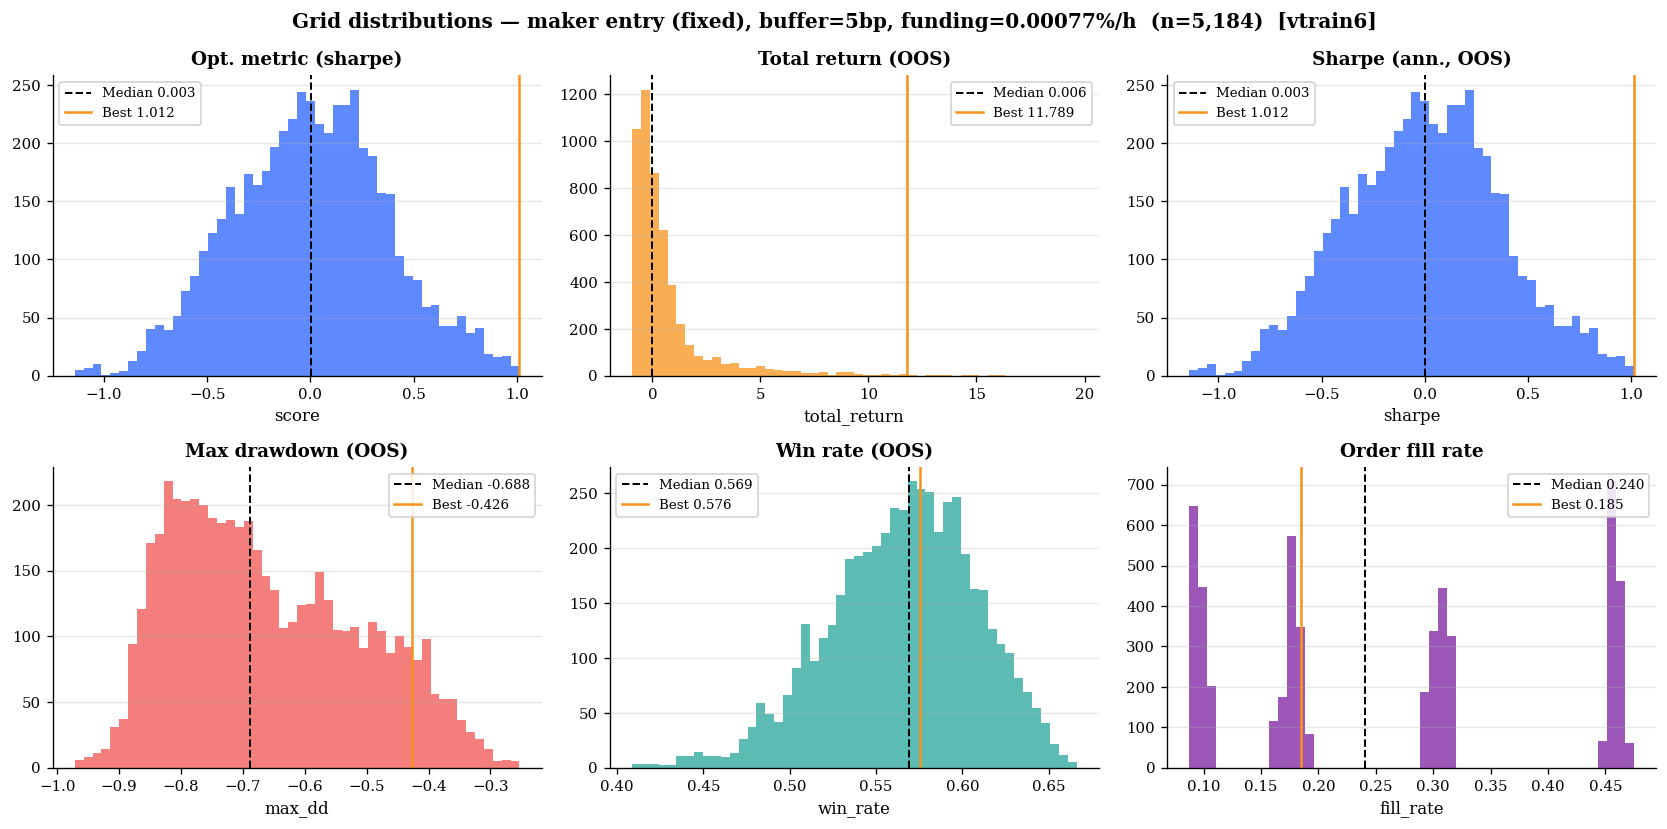

In [9]:
if not results_df.empty:
    plot_cols = [
        ('score',        f'Opt. metric ({OPTIMISE_METRIC})', BLUE),
        ('total_return', 'Total return (OOS)',               ACCENT),
        ('sharpe',       'Sharpe (ann., OOS)',               BLUE),
        ('max_dd',       'Max drawdown (OOS)',               RED),
        ('win_rate',     'Win rate (OOS)',                   GREEN),
        ('fill_rate',    'Order fill rate',                  PURPLE),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, (col, title, color) in zip(axes.flat, plot_cols):
        data = results_df[col]
        ax.hist(data, bins=50, color=color, alpha=0.75, edgecolor='none')
        ax.axvline(data.median(), color='black', lw=1.2, ls='--',
                   label=f'Median {data.median():.3f}')
        ax.axvline(results_df[col].iloc[0], color=ACCENT, lw=1.5,
                   label=f'Best {results_df[col].iloc[0]:.3f}')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel(col); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    fig.suptitle(
        f'Grid distributions — maker entry (fixed), buffer={BUFFER*1e4:.0f}bp, '
        f'funding={FUNDING_RATE_H*100:.5f}%/h  (n={len(results_df):,})  [vtrain6]',
        fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'grid_search_distributions_vtrain6.png'); plt.show()

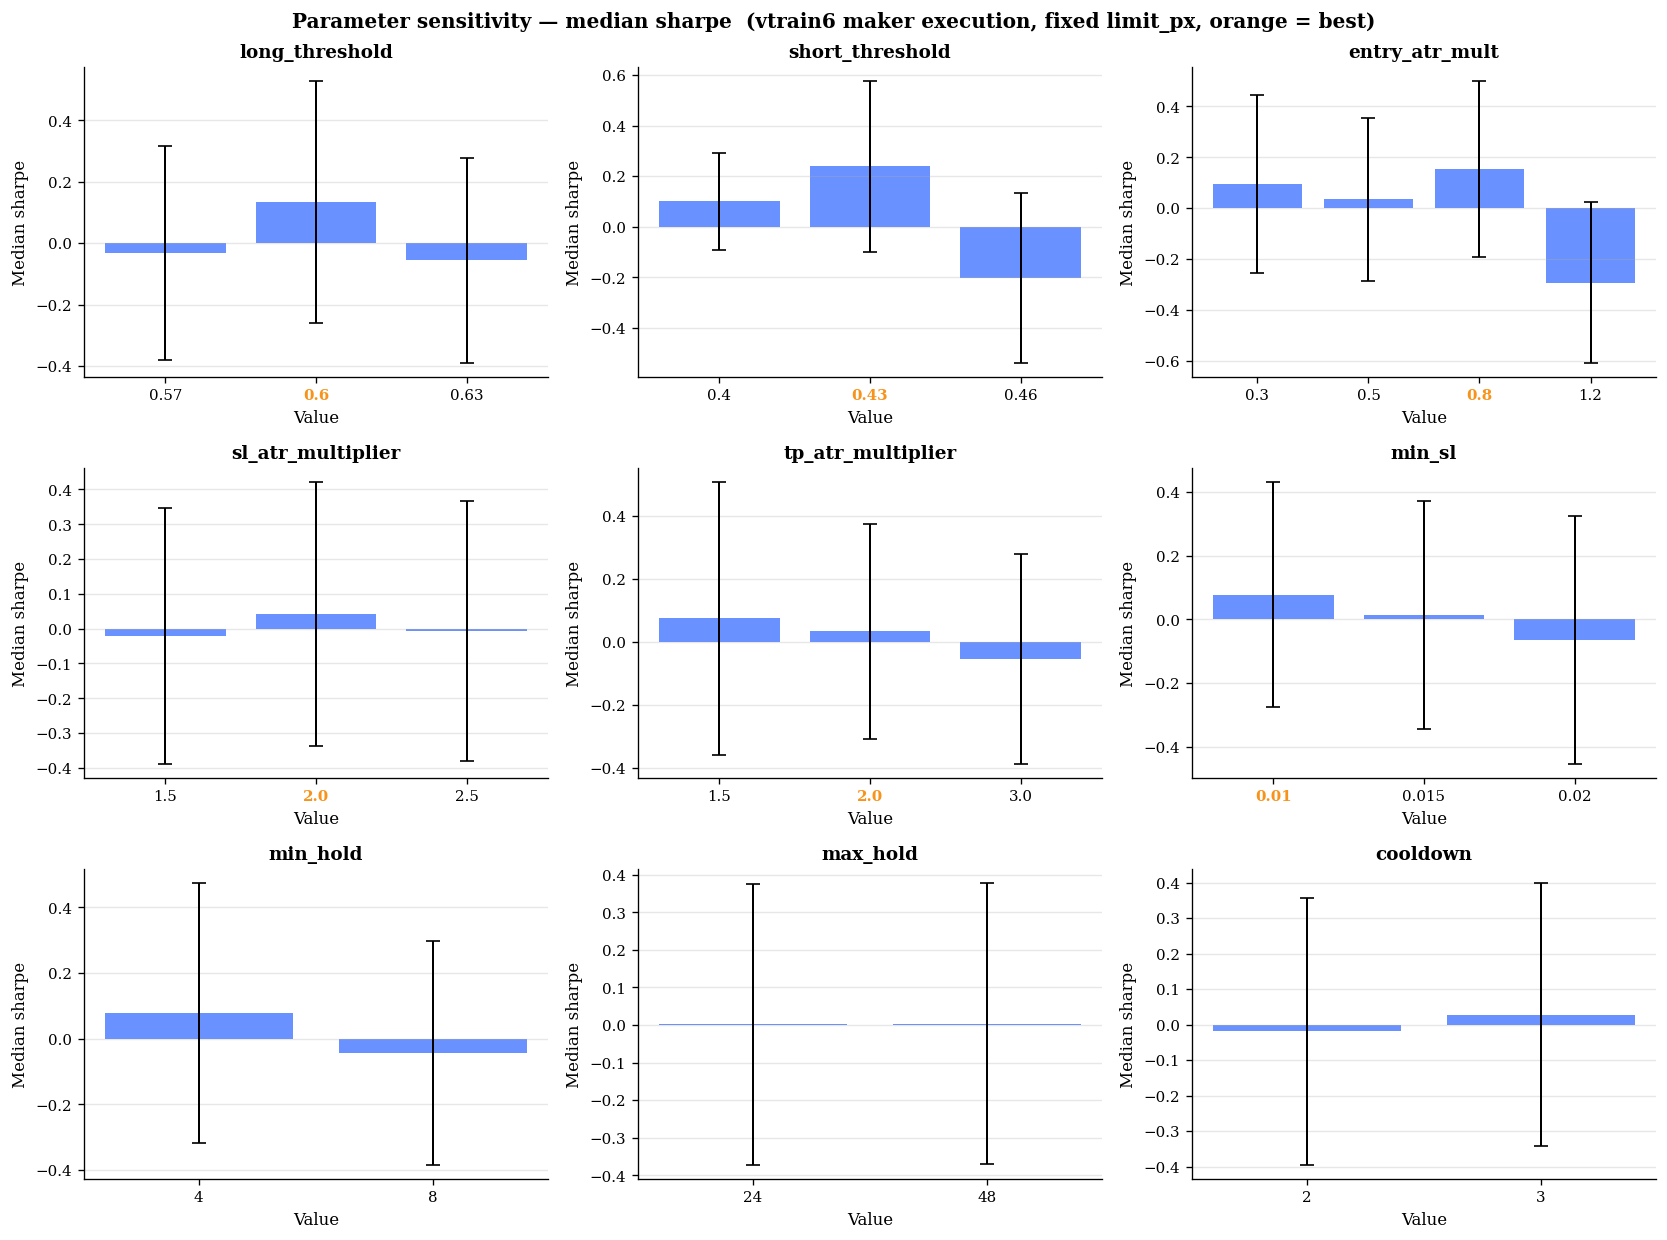

In [10]:
if not results_df.empty:
    n_params = len(keys)
    ncols = 3; nrows = int(np.ceil(n_params / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
    for ax, param in zip(axes.flat, keys):
        grp = results_df.groupby(param)['score'].agg(['median', 'std']).reset_index()
        x   = grp[param].astype(str)
        ax.bar(x, grp['median'], color=BLUE, alpha=0.7)
        ax.errorbar(x, grp['median'], yerr=grp['std'],
                    fmt='none', color='black', capsize=4, lw=1.2)
        ax.set_title(param, fontweight='bold')
        ax.set_xlabel('Value'); ax.set_ylabel(f'Median {OPTIMISE_METRIC}')
        ax.grid(axis='y', alpha=0.3)
        best_val = str(best[param])
        for tick in ax.get_xticklabels():
            if tick.get_text() == best_val:
                tick.set_color(ACCENT); tick.set_fontweight('bold')
    for ax in axes.flat[n_params:]:
        ax.set_visible(False)
    fig.suptitle(f'Parameter sensitivity — median {OPTIMISE_METRIC}  '
                 f'(vtrain6 maker execution, fixed limit_px, orange = best)', fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'grid_search_sensitivity_vtrain6.png'); plt.show()

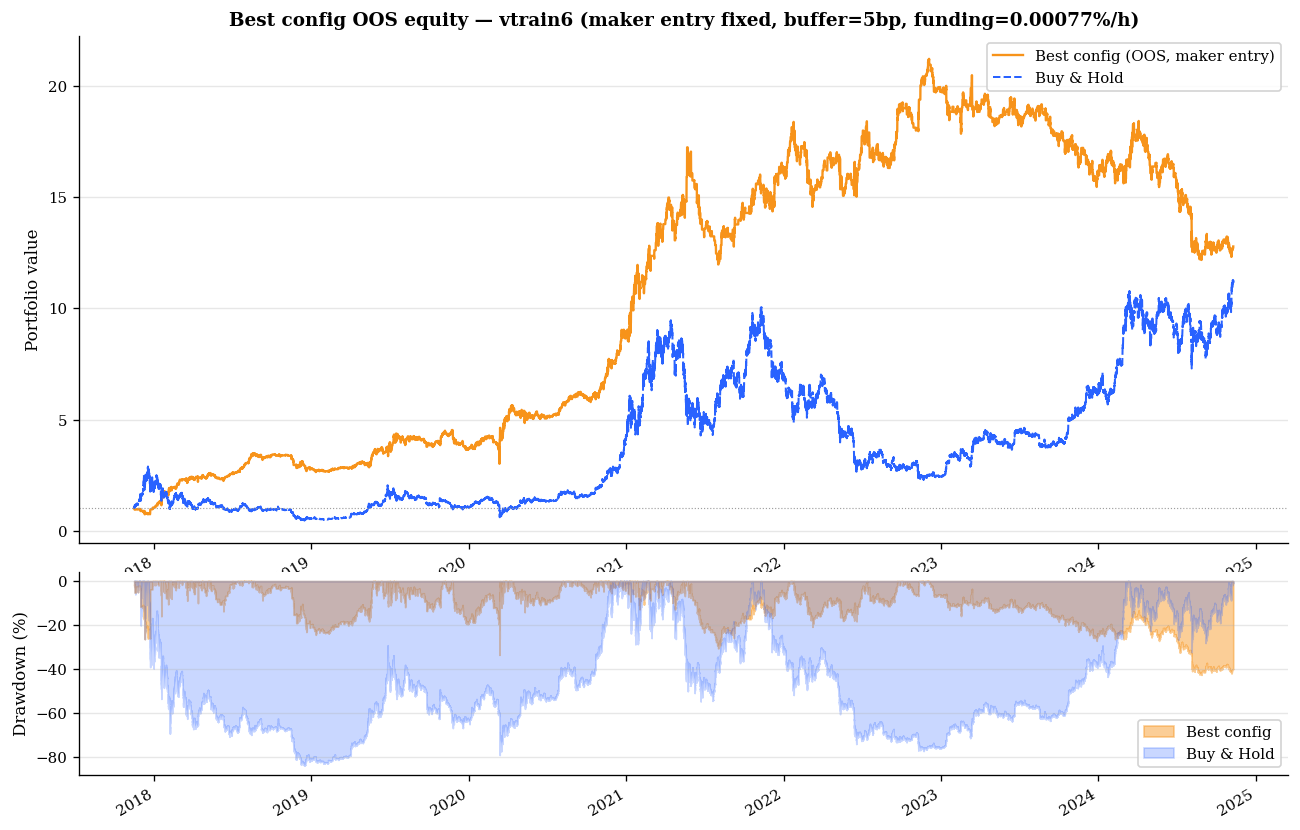

OOS K-Fold  |  Sharpe=1.012  Return=+1178.91%  MaxDD=-42.63%  Trades=1692  FillRate=18.5%


In [11]:
if not results_df.empty:
    eq_oos, tdf_oos = run_backtest(oos_probs, oos_close, oos_high, oos_low, oos_atr,
                                    oos_index, best_params)
    bh_oos = oos_close / oos_close[0]

    fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                              gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})
    ax = axes[0]
    ax.plot(oos_index, eq_oos, color=ACCENT, lw=1.4, label='Best config (OOS, maker entry)')
    ax.plot(oos_index, bh_oos, color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
    ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
    ax.set_ylabel('Portfolio value'); ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'Best config OOS equity — vtrain6 (maker entry fixed, buffer={BUFFER*1e4:.0f}bp, '
                 f'funding={FUNDING_RATE_H*100:.5f}%/h)', fontweight='bold')

    ax = axes[1]
    pk_s = np.maximum.accumulate(eq_oos); pk_b = np.maximum.accumulate(bh_oos)
    ax.fill_between(oos_index, (eq_oos - pk_s)/(pk_s+1e-12)*100, 0,
                    color=ACCENT, alpha=0.45, label='Best config')
    ax.fill_between(oos_index, (bh_oos - pk_b)/(pk_b+1e-12)*100, 0,
                    color=BLUE, alpha=0.25, label='Buy & Hold')
    ax.set_ylabel('Drawdown (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'grid_oos_best_equity_vtrain6.png'); plt.show()

    ret_oos = np.log(np.maximum(eq_oos[1:], 1e-12) / np.maximum(eq_oos[:-1], 1e-12))
    pk_oos  = np.maximum.accumulate(eq_oos)
    print(f'OOS K-Fold  |  Sharpe={ret_oos.mean()/(ret_oos.std(ddof=1)+1e-12)*np.sqrt(24*365):.3f}  '
          f'Return={eq_oos[-1]-1:+.2%}  MaxDD={((eq_oos-pk_oos)/(pk_oos+1e-12)).min():.2%}  '
          f'Trades={len(tdf_oos)}  FillRate={tdf_oos.attrs["n_fills"]/max(tdf_oos.attrs["n_signals"],1):.1%}')

## Phase 2 — Walk-Forward Optimization on Test Set

Monthly expanding-window LightGBM retrain (identical to vtrain4). WFO probabilities are fed
into the vtrain5 backtest engine (maker entry, penetration buffer, asymmetric fees, funding rate).

In [12]:
all_df = pd.concat([trainval_df, test_df]).sort_index()
n_tv   = len(trainval_df); n_test = len(test_df)
X_all  = all_df[selected_features].values
y_all  = all_df['label'].values

wfo_probs   = np.full(n_test, np.nan)
wfo_n_trees = []; step = 0

t0_wfo = time.perf_counter(); t = 0
while t < n_test:
    step_end    = min(t + WFO_STEP_H, n_test)
    n_wfo_train = n_tv + t
    X_wfo = X_all[:n_wfo_train]; y_wfo = y_all[:n_wfo_train]
    n_int  = min(WFO_INTERNAL_VAL_H, int(0.10 * n_wfo_train))
    X_vl_w = X_wfo[-n_int:]; y_vl_w = y_wfo[-n_int:]
    X_tr_w = X_wfo[:-n_int]; y_tr_w = y_wfo[:-n_int]

    ds_tr_w = lgb.Dataset(X_tr_w, label=y_tr_w, feature_name=selected_features)
    ds_vl_w = lgb.Dataset(X_vl_w, label=y_vl_w, feature_name=selected_features, reference=ds_tr_w)

    wfo_model = lgb.train(
        LGB_PARAMS, ds_tr_w,
        valid_sets=[ds_tr_w, ds_vl_w], valid_names=['train', 'val'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=WFO_PATIENCE, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    X_step = X_all[n_tv + t : n_tv + step_end]
    wfo_probs[t:step_end] = wfo_model.predict(X_step)
    wfo_n_trees.append(wfo_model.best_iteration)

    step += 1
    print(f'Step {step:>2}  train={n_wfo_train:,}  int_val={n_int:,}  '
          f'best_iter={wfo_model.best_iteration:>4}  '
          f'prob=[{wfo_probs[t:step_end].min():.3f},{wfo_probs[t:step_end].max():.3f}]  '
          f'{step_end/n_test*100:.0f}%')
    del wfo_model; t = step_end

print(f'WFO done — {step} steps {time.perf_counter()-t0_wfo:.1f}s  '
      f'best_iter mean={np.mean(wfo_n_trees):.0f}')

Step  1  train=61,118  int_val=2,500  best_iter= 143  prob=[0.366,0.675]  5%
Step  2  train=61,838  int_val=2,500  best_iter= 112  prob=[0.382,0.674]  11%
Step  3  train=62,558  int_val=2,500  best_iter= 268  prob=[0.293,0.700]  16%
Step  4  train=63,278  int_val=2,500  best_iter= 109  prob=[0.380,0.665]  22%
Step  5  train=63,998  int_val=2,500  best_iter=  94  prob=[0.403,0.646]  27%
Step  6  train=64,718  int_val=2,500  best_iter=  74  prob=[0.417,0.634]  33%
Step  7  train=65,438  int_val=2,500  best_iter=  66  prob=[0.417,0.627]  38%
Step  8  train=66,158  int_val=2,500  best_iter=  67  prob=[0.410,0.628]  43%
Step  9  train=66,878  int_val=2,500  best_iter= 111  prob=[0.389,0.651]  49%
Step 10  train=67,598  int_val=2,500  best_iter= 165  prob=[0.367,0.643]  54%
Step 11  train=68,318  int_val=2,500  best_iter= 199  prob=[0.352,0.671]  60%
Step 12  train=69,038  int_val=2,500  best_iter= 203  prob=[0.357,0.666]  65%
Step 13  train=69,758  int_val=2,500  best_iter= 112  prob=[0.361

In [13]:
bh_test = test_close / test_close[0]

# vtrain6 WFO (maker entry FIXED + buffer + asymmetric fees + funding)
eq_wfo6, tdf_wfo6 = run_backtest(
    wfo_probs, test_close, test_high, test_low, test_atr, test_index, best_params)

# vtrain6 on static production model (same execution)
prod_model    = lgb.Booster(model_file=str(MODELS_DIR / 'lgbm_model.txt'))
probs_static  = prod_model.predict(X_test)
eq_static6, tdf_static6 = run_backtest(
    probs_static, test_close, test_high, test_low, test_atr, test_index, best_params)

# vtrain4 WFO for comparison (intra-candle H/L, taker fees, no maker logic)
def run_backtest_v4(probs, close_arr, high_arr, low_arr, atr_arr, sig_index, params, fee=0.001):
    """vtrain4 engine: intra-candle SL/TP, flat 0.1% fee each side."""
    lt=params['long_threshold']; st=params['short_threshold']
    el=1-lt; es=1-st
    slm=params['sl_atr_multiplier']; tpm=params['tp_atr_multiplier']
    msl=params['min_sl']; mnh=int(params['min_hold']); mxh=int(params['max_hold'])
    cdn=int(params['cooldown'])
    cash=1.0; units=0.0; ec=0.0; in_pos=False; dir_=None
    epx=0.0; dsl=0.0; dtp=0.0; hc=0; cd=0
    eq=[1.0]; tl=[]
    for i,(ts,px,hi,lo,cf,at) in enumerate(zip(sig_index,close_arr,high_arr,low_arr,probs,atr_arr)):
        if cd>0: cd-=1
        r=None; xpx=px; pnl=0.0
        if in_pos:
            hc+=1
            if dir_=='long':
                slp=epx*(1-dsl); tpp=epx*(1+dtp)
                if lo<=slp and hi>=tpp: r='sl'; xpx=slp
                elif lo<=slp: r='sl'; xpx=slp
                elif hi>=tpp: r='tp'; xpx=tpp
                elif hc>=mxh: r='max_hold'
                elif hc>=mnh and cf<el: r='conf'
                if r: pnl=(xpx-epx)/epx; cash=units*xpx*(1-fee); units=0.0
            else:
                slp=epx*(1+dsl); tpp=epx*(1-dtp)
                if hi>=slp and lo<=tpp: r='sl'; xpx=slp
                elif hi>=slp: r='sl'; xpx=slp
                elif lo<=tpp: r='tp'; xpx=tpp
                elif hc>=mxh: r='max_hold'
                elif hc>=mnh and cf>es: r='conf'
                if r:
                    g=(epx-xpx)/epx; pnl=g; cash=ec*(1+g)*(1-fee)
            if r: tl.append({'direction':dir_,'pnl_pct':pnl,'hold_h':hc,'reason':r}); in_pos=False; hc=0; cd=cdn
        if not in_pos and cd==0:
            dsl=max(slm*at,msl); dtp=tpm*at
            if cf>=lt: units=cash*(1-fee)/px; cash=0.0; in_pos=True; dir_='long'; epx=px; hc=0
            elif cf<=st: ec=cash*(1-fee); units=ec/px; in_pos=True; dir_='short'; epx=px; hc=0
        if in_pos and dir_=='long': eq.append(units*px)
        elif in_pos and dir_=='short': eq.append(ec*(1+(epx-px)/epx))
        else: eq.append(cash)
    if in_pos:
        px=close_arr[-1]
        if dir_=='long': g=(px-epx)/epx; cash=units*px*(1-fee)
        else: g=(epx-px)/epx; cash=ec*(1+g)*(1-fee)
        tl.append({'direction':dir_,'pnl_pct':g,'hold_h':hc,'reason':'eod'}); eq[-1]=cash
    return np.array(eq[1:]), pd.DataFrame(tl)

# Load vtrain3 best params for comparison (zero-fee baseline that worked)
v3_path = MODELS_DIR / 'lgbm_best_trading_params_vtrain3.json'
v4_path = MODELS_DIR / 'lgbm_best_trading_params_vtrain4.json'

if v3_path.exists():
    with open(v3_path) as f: v3_data = json.load(f)
    v3_params = v3_data['params']
    # vtrain3 engine has no fees/H&L — just close-based, no entry pending
    # run vtrain4 engine with fee=0 as closest proxy
    eq_wfo3, tdf_wfo3 = run_backtest_v4(wfo_probs, test_close, test_high, test_low, test_atr, test_index, v3_params, fee=0.0)
else:
    eq_wfo3, tdf_wfo3 = None, None

if v4_path.exists():
    with open(v4_path) as f: v4_data = json.load(f)
    v4_params = v4_data['params']
    eq_wfo4, tdf_wfo4 = run_backtest_v4(wfo_probs, test_close, test_high, test_low, test_atr, test_index, v4_params)
else:
    eq_wfo4, tdf_wfo4 = None, None

def quick(eq, tdf, label):
    if eq is None: print(f'  {label}  — SKIPPED (no params file)'); return
    ret=np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12))
    pk=np.maximum.accumulate(eq)
    sh=float(ret.mean()/(ret.std(ddof=1)+1e-12)*np.sqrt(24*365))
    mdd=float(((eq-pk)/(pk+1e-12)).min())
    wr=float((tdf['pnl_pct']>0).mean()) if not tdf.empty else float('nan')
    fr=tdf.attrs.get('n_fills',0)/max(tdf.attrs.get('n_signals',1),1) if hasattr(tdf,'attrs') else float('nan')
    print(f'  {label:<52}  Return={eq[-1]-1:+.2%}  Sharpe={sh:.3f}  MaxDD={mdd:.2%}  '
          f'Trades={len(tdf)}  WR={wr:.1%}  Fill={fr:.0%}')

print('── Test results ─────────────────────────────────────────────────────────────')
if eq_wfo3 is not None: quick(eq_wfo3, tdf_wfo3, 'vtrain3 params  (H/L sim, 0% fee, reference)')
if eq_wfo4 is not None: quick(eq_wfo4, tdf_wfo4, 'vtrain4 WFO  (H/L, 0.1% flat fee)')
quick(eq_wfo6,    tdf_wfo6,    f'vtrain6 WFO  (maker entry FIXED, buf={BUFFER*1e4:.0f}bp, fund)')
quick(eq_static6, tdf_static6, f'vtrain6 static  (maker entry FIXED, buf={BUFFER*1e4:.0f}bp)')
quick(bh_test,    pd.DataFrame(), 'Buy & Hold')

── Test results ─────────────────────────────────────────────────────────────
  vtrain3 params  (H/L sim, 0% fee, reference)          Return=+48.54%  Sharpe=0.845  MaxDD=-17.56%  Trades=989  WR=65.3%  Fill=0%
  vtrain4 WFO  (H/L, 0.1% flat fee)                     Return=-18.15%  Sharpe=-0.674  MaxDD=-30.96%  Trades=166  WR=50.6%  Fill=0%
  vtrain6 WFO  (maker entry FIXED, buf=5bp, fund)       Return=-19.06%  Sharpe=-0.933  MaxDD=-27.81%  Trades=171  WR=49.7%  Fill=17%
  vtrain6 static  (maker entry FIXED, buf=5bp)          Return=-16.93%  Sharpe=-0.780  MaxDD=-25.36%  Trades=212  WR=52.8%  Fill=16%
  Buy & Hold                                            Return=+3.14%  Sharpe=0.044  MaxDD=-50.08%  Trades=0  WR=nan%  Fill=0%


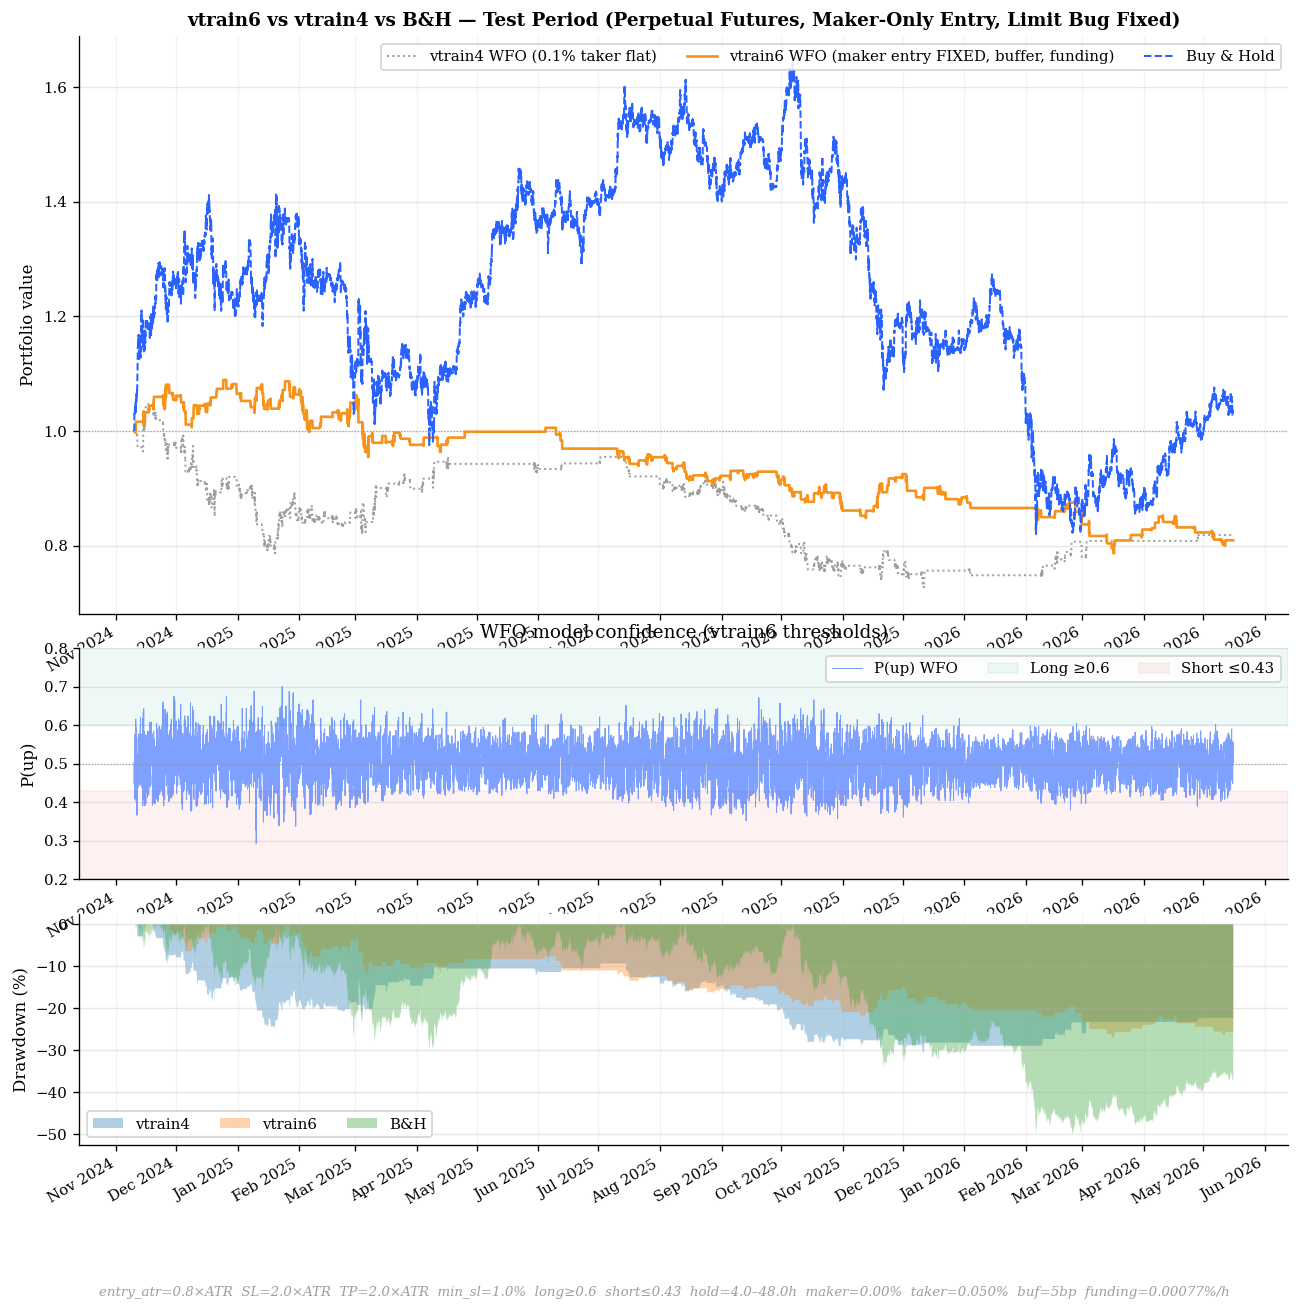

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12),
                          gridspec_kw={'height_ratios': [3, 1.2, 1.2], 'hspace': 0.10})

ax = axes[0]
if eq_wfo4 is not None:
    ax.plot(test_index, eq_wfo4, color=GREY,   lw=1.2, ls=':',  label='vtrain4 WFO (0.1% taker flat)')
ax.plot(test_index, eq_wfo6,    color=ACCENT, lw=1.6,           label='vtrain6 WFO (maker entry FIXED, buffer, funding)')
ax.plot(test_index, bh_test,    color=BLUE,   lw=1.2, ls='--',  label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value')
ax.set_title('vtrain6 vs vtrain4 vs B&H — Test Period (Perpetual Futures, Maker-Only Entry, Limit Bug Fixed)',
             fontweight='bold')
ax.legend(ncol=3); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax = axes[1]
ax.plot(test_index, wfo_probs, color=BLUE, lw=0.6, alpha=0.6, label='P(up) WFO')
ax.axhspan(best_params['long_threshold'],  1.0, alpha=0.08, color=GREEN,
           label=f'Long ≥{best_params["long_threshold"]}')
ax.axhspan(0.0, best_params['short_threshold'], alpha=0.08, color=RED,
           label=f'Short ≤{best_params["short_threshold"]}')
ax.axhline(0.5, color=GREY, ls=':', lw=0.7)
ax.set_ylim(0.2, 0.8); ax.set_ylabel('P(up)')
ax.set_title('WFO model confidence (vtrain6 thresholds)')
ax.legend(ncol=3); ax.grid(axis='y', alpha=0.3)

ax = axes[2]
dd_series = [(eq_wfo6, test_index, ACCENT, 'vtrain6'), (bh_test, test_index, BLUE, 'B&H')]
if eq_wfo4 is not None:
    dd_series.insert(0, (eq_wfo4, test_index, GREY, 'vtrain4'))
for eq, idx, color, lbl in dd_series:
    pk = np.maximum.accumulate(eq)
    ax.fill_between(idx, (eq-pk)/(pk+1e-12)*100, 0, alpha=0.35, label=lbl)
ax.set_ylabel('Drawdown (%)'); ax.legend(ncol=3)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.005,
    f'entry_atr={best_params["entry_atr_mult"]}×ATR  SL={best_params["sl_atr_multiplier"]}×ATR  '
    f'TP={best_params["tp_atr_multiplier"]}×ATR  min_sl={best_params["min_sl"]*100:.1f}%  '
    f'long≥{best_params["long_threshold"]}  short≤{best_params["short_threshold"]}  '
    f'hold={best_params["min_hold"]}–{best_params["max_hold"]}h  '
    f'maker={MAKER_FEE*100:.2f}%  taker={TAKER_FEE*100:.3f}%  buf={BUFFER*1e4:.0f}bp  '
    f'funding={FUNDING_RATE_H*100:.5f}%/h',
    ha='center', fontsize=8, color=GREY, style='italic')
fig.savefig(FIGURES_DIR / 'grid_wfo_equity_vtrain6.png'); plt.show()

In [15]:
def full_metrics(eq, tdf, label):
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    pk  = np.maximum.accumulate(eq)
    sh  = float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))
    mdd = float(((eq - pk) / (pk + 1e-12)).min())
    an  = float((eq[-1] ** (24 * 365 / len(eq))) - 1)
    cal = an / (abs(mdd) + 1e-6)
    wr  = float((tdf['pnl_pct'] > 0).mean()) if not tdf.empty else float('nan')
    pf  = 0.0
    if not tdf.empty:
        g  = tdf[tdf['pnl_pct'] > 0]['pnl_pct'].sum()
        l  = tdf[tdf['pnl_pct'] < 0]['pnl_pct'].abs().sum()
        pf = g / (l + 1e-6)
    fr = tdf.attrs.get('n_fills',0)/max(tdf.attrs.get('n_signals',1),1) if hasattr(tdf,'attrs') else float('nan')
    return {
        'Strategy':      label,
        'Total Return':  f'{eq[-1]-1:+.2%}',
        'Ann. Return':   f'{an:+.2%}',
        'Sharpe (ann.)': f'{sh:.3f}',
        'Max Drawdown':  f'{mdd:.2%}',
        'Calmar':        f'{cal:.3f}',
        'Win Rate':      f'{wr:.1%}' if not np.isnan(wr) else 'N/A',
        'Profit Factor': f'{pf:.3f}',
        'Trades':        str(len(tdf)),
        'Fill Rate':     f'{fr:.1%}' if not np.isnan(fr) else 'N/A',
    }

rows = []
if eq_wfo4 is not None:
    rows.append(full_metrics(eq_wfo4, tdf_wfo4, 'vtrain4 WFO  (H/L intra-candle, 0.10% flat fee, no funding)'))
rows += [
    full_metrics(eq_wfo6,    tdf_wfo6,    f'vtrain6 WFO  (maker entry FIXED, {BUFFER*1e4:.0f}bp buf, funding, asym fees)'),
    full_metrics(eq_static6, tdf_static6, 'vtrain6 static model (same execution)'),
    full_metrics(bh_test,    pd.DataFrame(), 'Buy & Hold'),
]
summary = pd.DataFrame(rows).set_index('Strategy')

print('\n' + '='*90)
print('  FINAL TEST-SET SUMMARY — vtrain6')
print('='*90)
print(summary.to_string())
print('='*90)

# Funding drag estimate on vtrain6 trades
if not tdf_wfo6.empty:
    avg_hold = tdf_wfo6['hold_h'].mean()
    funding_drag_per_trade = FUNDING_RATE_H * LEVERAGE * avg_hold
    print(f'\n  Avg hold {avg_hold:.1f}h → funding drag per trade ≈ {funding_drag_per_trade*100:.4f}%')
    print(f'  Over {len(tdf_wfo6)} trades → total funding drag ≈ {funding_drag_per_trade*len(tdf_wfo6)*100:.3f}%')


  FINAL TEST-SET SUMMARY — vtrain6
                                                              Total Return Ann. Return Sharpe (ann.) Max Drawdown  Calmar Win Rate Profit Factor Trades Fill Rate
Strategy                                                                                                                                                         
vtrain4 WFO  (H/L intra-candle, 0.10% flat fee, no funding)        -18.15%     -12.40%        -0.674      -30.96%  -0.401    50.6%         1.132    166      0.0%
vtrain6 WFO  (maker entry FIXED, 5bp buf, funding, asym fees)      -19.06%     -13.05%        -0.933      -27.81%  -0.469    49.7%         0.876    171     16.6%
vtrain6 static model (same execution)                              -16.93%     -11.54%        -0.780      -25.36%  -0.455    52.8%         0.929    212     15.9%
Buy & Hold                                                          +3.14%      +2.07%         0.044      -50.08%   0.041      N/A         0.000      0   

In [16]:
results_path = MODELS_DIR / 'lgbm_grid_results_vtrain6.csv'
results_df.to_csv(results_path, index=False)
print(f'Saved {len(results_df):,} grid results → {results_path}')

ret_w  = np.log(np.maximum(eq_wfo6[1:], 1e-12) / np.maximum(eq_wfo6[:-1], 1e-12))
pk_w   = np.maximum.accumulate(eq_wfo6)
ret_oos2 = np.log(np.maximum(eq_oos[1:], 1e-12) / np.maximum(eq_oos[:-1], 1e-12))
pk_oos2  = np.maximum.accumulate(eq_oos)

output = {
    'version': 'vtrain6',
    'bug_fix': 'limit_px formula corrected: px*(1-ent_atr*atr_pct) instead of px-ent_atr*atr_pct',
    'changes_vs_vtrain5': [
        'BUG FIX: limit_px = close*(1 - entry_atr_mult*atr_14_pct) — proper fractional pullback',
        'entry_atr_mult grid widened to [0.3, 0.5, 0.8, 1.2] to explore optimal pullback depth',
    ],
    'changes_vs_vtrain4': [
        'Maker-only entry: limit order at Close*(1 - entry_atr_mult*ATR_pct) (no taker fee at entry)',
        f'Penetration buffer {BUFFER*1e4:.0f}bp: wick must clear limit_px*(1±BUFFER) for FIFO guarantee',
        f'Asymmetric fees: Maker={MAKER_FEE*100:.2f}% (entries/TP), Taker={TAKER_FEE*100:.3f}% (SL/time exits)',
        f'Funding rate drag: {FUNDING_RATE_H*100:.5f}%/h × leverage (≈0.0062%/8h MEXC)',
        f'Leverage parameter: {LEVERAGE}',
    ],
    'maker_fee':        MAKER_FEE,
    'taker_fee':        TAKER_FEE,
    'leverage':         LEVERAGE,
    'buffer':           BUFFER,
    'funding_rate_h':   FUNDING_RATE_H,
    'selection_method': 'purged_kfold_trainval',
    'wfo_retrain_freq': f'{WFO_STEP_H}h',
    'params':           best_params,
    'oos_kfold': {
        'sharpe':       round(float(ret_oos2.mean()/(ret_oos2.std(ddof=1)+1e-12)*np.sqrt(24*365)), 4),
        'total_return': round(float(eq_oos[-1] - 1), 4),
        'max_dd':       round(float(((eq_oos-pk_oos2)/(pk_oos2+1e-12)).min()), 4),
        'n_trades':     int(len(tdf_oos)),
        'fill_rate':    round(tdf_oos.attrs.get('n_fills',0)/max(tdf_oos.attrs.get('n_signals',1),1), 4),
    },
    'test_wfo': {
        'sharpe':       round(float(ret_w.mean()/(ret_w.std(ddof=1)+1e-12)*np.sqrt(24*365)), 4),
        'total_return': round(float(eq_wfo6[-1] - 1), 4),
        'max_dd':       round(float(((eq_wfo6-pk_w)/(pk_w+1e-12)).min()), 4),
        'n_trades':     int(len(tdf_wfo6)),
        'fill_rate':    round(tdf_wfo6.attrs.get('n_fills',0)/max(tdf_wfo6.attrs.get('n_signals',1),1), 4),
    },
}

params_path = MODELS_DIR / 'lgbm_best_trading_params_vtrain6.json'
with open(params_path, 'w') as f:
    json.dump(output, f, indent=2)
print(f'Saved best params → {params_path}')
print()
print(json.dumps(output, indent=2))

Saved 5,184 grid results → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/lgbm_grid_results_vtrain6.csv
Saved best params → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/lgbm_best_trading_params_vtrain6.json

{
  "version": "vtrain6",
  "bug_fix": "limit_px formula corrected: px*(1-ent_atr*atr_pct) instead of px-ent_atr*atr_pct",
  "changes_vs_vtrain5": [
    "BUG FIX: limit_px = close*(1 - entry_atr_mult*atr_14_pct) \u2014 proper fractional pullback",
    "entry_atr_mult grid widened to [0.3, 0.5, 0.8, 1.2] to explore optimal pullback depth"
  ],
  "changes_vs_vtrain4": [
    "Maker-only entry: limit order at Close*(1 - entry_atr_mult*ATR_pct) (no taker fee at entry)",
    "Penetration buffer 5bp: wick must clear limit_px*(1\u00b1BUFFER) for FIFO guarantee",
    "Asymmetric fees: Maker=0.00% (entries/TP), Taker=0.050% (SL/time exits)",
    "Funding rate drag: 0.00077%/h \u00d7 leverage (\u22480.0062%/8h MEXC)",
    "Le